In [15]:
import pandas as pd

df = pd.read_csv("glass_experiment_numeric_only.csv")

print(df.columns)
print(df.head())

Index(['record_id', 'date_yyyymmdd', 'year', 'month', 'day',
       'experiment_round', 'days_since_first', 'temperature_c',
       'temperature_step_code', 'maker_id', 'maker_count',
       'pre_image_available', 'post_image_available', 'result_code',
       'temp_condition_code', 'overheat_score', 'particle_score',
       'volume_score', 'transparency_score', 'success_score',
       'overall_quality_score_100', 'source_page', 'source_doc_row_order',
       'hold_time_min'],
      dtype='object')
   record_id  date_yyyymmdd  year  month  day  experiment_round  \
0          1       20250508  2025      5    8                 1   
1          2       20250508  2025      5    8                 1   
2          3       20250508  2025      5    8                 1   
3          4       20250508  2025      5    8                 1   
4          5       20250508  2025      5    8                 1   

   days_since_first  temperature_c  temperature_step_code  maker_id  ...  \
0                 

In [16]:
print(df["hold_time_min"].describe())

print(df["hold_time_min"].unique())

print(df["hold_time_min"].isna().sum())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: hold_time_min, dtype: float64
[nan]
30


In [17]:
print(df["temperature_c"].value_counts())

temperature_c
760    13
800    10
780     7
Name: count, dtype: int64


In [18]:
print(df.shape)
print(df_time.shape)

(30, 24)
(0, 24)


In [19]:
df[[
    "temperature_c",
    "hold_time_min",
    "overall_quality_score_100"
]].head(20)

,temperature_c,hold_time_min,overall_quality_score_100
0,800,NaN,20
1,800,NaN,20
2,800,NaN,20
3,800,NaN,20
4,800,NaN,20
5,800,NaN,20
6,800,NaN,20
7,800,NaN,20
8,800,NaN,20
9,800,NaN,20


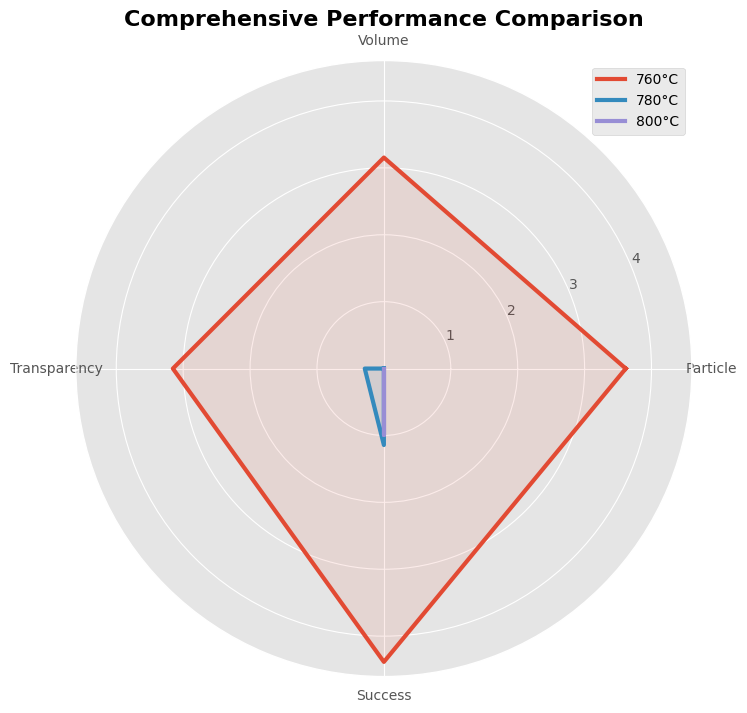

In [35]:
import numpy as np

metrics = [
    "particle_score",
    "volume_score",
    "transparency_score",
    "success_score"
]

group = (
    df.groupby("temperature_c")[metrics]
    .mean()
)

labels = metrics

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
)

angles = np.concatenate(
    (angles,[angles[0]])
)

fig = plt.figure(
    figsize=(8,8)
)

ax = plt.subplot(
    111,
    polar=True
)

for temp in group.index:

    values = group.loc[temp].tolist()
    values += [values[0]]

    ax.plot(
        angles,
        values,
        linewidth=3,
        label=f"{temp}°C"
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels([
    "Particle",
    "Volume",
    "Transparency",
    "Success"
])

plt.title(
    "Comprehensive Performance Comparison",
    fontsize=16,
    weight="bold"
)

plt.legend()

plt.savefig(
    "03_radar_chart.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

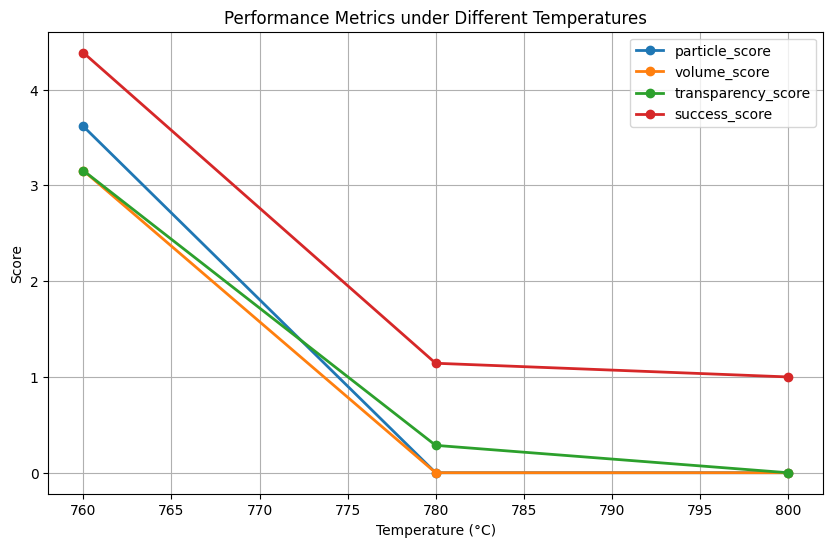

In [32]:
metrics = [
    "particle_score",
    "volume_score",
    "transparency_score",
    "success_score"
]

group = (
    df.groupby("temperature_c")[metrics]
    .mean()
)

plt.figure(figsize=(10,6))

for metric in metrics:

    plt.plot(
        group.index,
        group[metric],
        marker="o",
        linewidth=2,
        label=metric
    )

plt.title("Performance Metrics under Different Temperatures")
plt.xlabel("Temperature (°C)")
plt.ylabel("Score")

plt.legend()

plt.grid(True)

plt.savefig(
    "multi_metric_line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

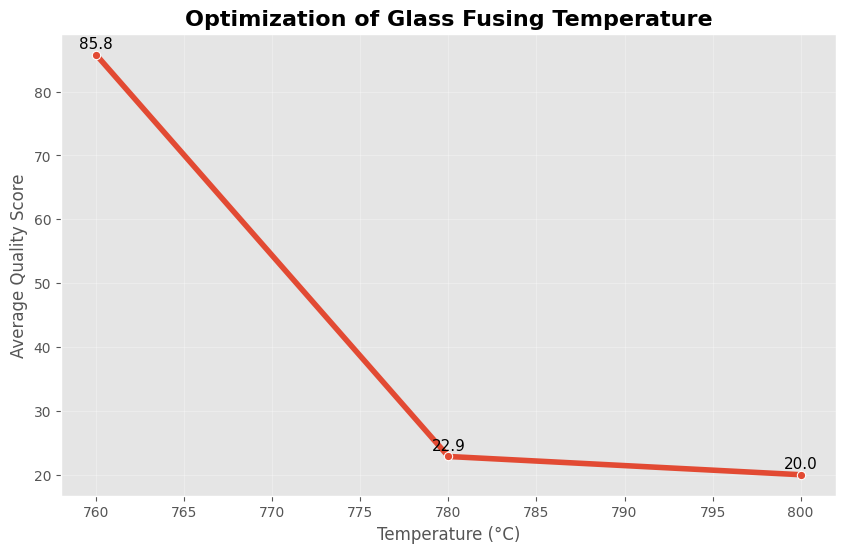

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv("glass_experiment_numeric_only.csv")

temp_quality = (
    df.groupby("temperature_c")["overall_quality_score_100"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=temp_quality,
    x="temperature_c",
    y="overall_quality_score_100",
    marker="o",
    linewidth=4
)

for x,y in zip(
    temp_quality["temperature_c"],
    temp_quality["overall_quality_score_100"]
):
    plt.text(
        x,
        y+1,
        f"{y:.1f}",
        ha='center',
        fontsize=11
    )

plt.title(
    "Optimization of Glass Fusing Temperature",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Average Quality Score")

plt.grid(alpha=0.3)

plt.savefig(
    "01_temperature_optimization.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

quxian

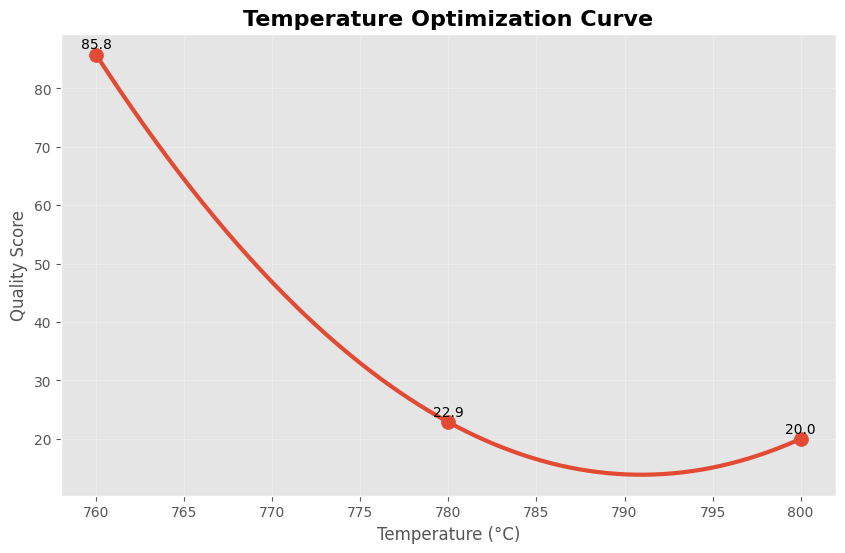

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

df = pd.read_csv("glass_experiment_numeric_only.csv")

temp_quality = (
    df.groupby("temperature_c")["overall_quality_score_100"]
    .mean()
    .reset_index()
)

x = temp_quality["temperature_c"]
y = temp_quality["overall_quality_score_100"]

# 平滑曲线
x_smooth = np.linspace(
    x.min(),
    x.max(),
    300
)

spl = make_interp_spline(
    x,
    y,
    k=2
)

y_smooth = spl(x_smooth)

plt.figure(figsize=(10,6))

plt.plot(
    x_smooth,
    y_smooth,
    linewidth=3
)

plt.scatter(
    x,
    y,
    s=100
)

for xi,yi in zip(x,y):

    plt.text(
        xi,
        yi+1,
        f"{yi:.1f}",
        ha="center"
    )

plt.title(
    "Temperature Optimization Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Quality Score")

plt.grid(alpha=0.3)

plt.savefig(
    "temperature_curve.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

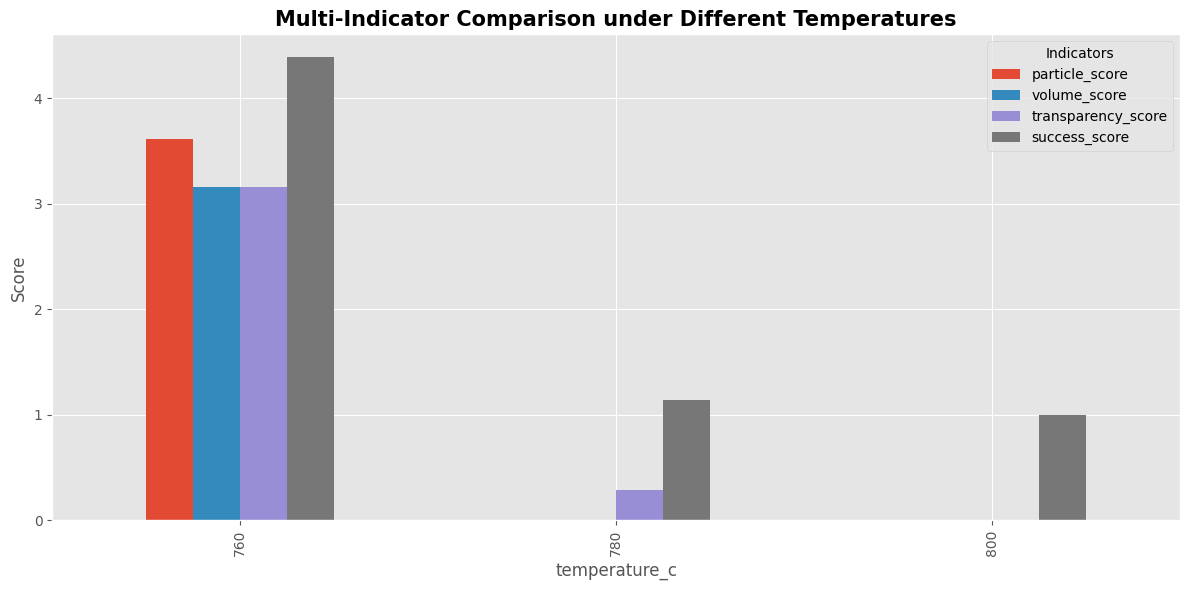

In [34]:
metrics = [
    "particle_score",
    "volume_score",
    "transparency_score",
    "success_score"
]

compare = (
    df.groupby("temperature_c")[metrics]
    .mean()
)

compare.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Multi-Indicator Comparison under Different Temperatures",
    fontsize=15,
    weight="bold"
)

plt.ylabel("Score")

plt.legend(
    title="Indicators"
)

plt.tight_layout()

plt.savefig(
    "02_multi_indicator.png",
    dpi=600
)

plt.show()

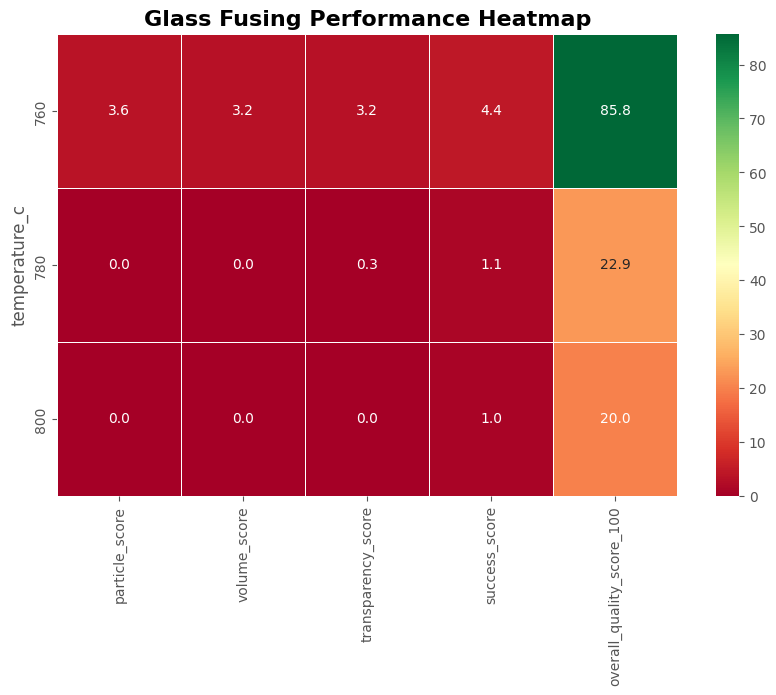

In [36]:
heat_data = (
    df.groupby("temperature_c")[
        [
            "particle_score",
            "volume_score",
            "transparency_score",
            "success_score",
            "overall_quality_score_100"
        ]
    ]
    .mean()
)

plt.figure(
    figsize=(10,6)
)

sns.heatmap(
    heat_data,
    annot=True,
    cmap="RdYlGn",
    linewidths=0.5,
    fmt=".1f"
)

plt.title(
    "Glass Fusing Performance Heatmap",
    fontsize=16,
    weight="bold"
)

plt.savefig(
    "04_performance_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()